In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv("data/raw/data.csv", engine="python", on_bad_lines="skip")

In [10]:
df.head()

,BioSample,Organism group,Scientific name,Isolation type,Location,Isolation source,Isolate,Antibiotic,Resistance phenotype,Measurement sign,MIC (mg/L),Disk diffusion (mm),Laboratory typing platform,Vendor,Laboratory typing method version or reagent,Testing standard,Create date
0,SAMN02640777,Salmonella enterica,"Salmonella enterica subsp. enterica serovar 4,...",environmental/other,USA,chicken breast,PDT000003687.3,amikacin,susceptible,==,1.0,NaN,NaN,NaN,NaN,CLSI,2015-02-11T08:09:23Z
1,SAMN02640778,Salmonella enterica,Salmonella enterica subsp. enterica serovar Ke...,environmental/other,USA,chicken breast,PDT000003688.4,amikacin,susceptible,==,2.0,NaN,NaN,NaN,NaN,CLSI,2015-02-10T22:08:35Z
2,SAMN02640780,Salmonella enterica,Salmonella enterica subsp. enterica serovar Ke...,environmental/other,USA,chicken breast,PDT000003689.4,amikacin,susceptible,==,4.0,NaN,NaN,NaN,NaN,CLSI,2015-02-10T22:08:35Z
3,SAMN02640788,Salmonella enterica,Salmonella enterica subsp. enterica serovar Hadar,environmental/other,USA,chicken breast,PDT000003690.3,amikacin,susceptible,==,1.0,NaN,NaN,NaN,NaN,CLSI,2015-02-10T22:08:35Z
4,SAMN02640789,Salmonella enterica,Salmonella enterica subsp. enterica,environmental/other,USA,pork chop,PDT000003691.3,amikacin,susceptible,==,1.0,NaN,NaN,NaN,NaN,CLSI,2015-02-10T22:08:35Z


In [11]:
df.shape

(494079, 17)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494079 entries, 0 to 494078
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   BioSample                                    494079 non-null  object 
 1   Organism group                               494079 non-null  object 
 2   Scientific name                              494079 non-null  object 
 3   Isolation type                               492358 non-null  object 
 4   Location                                     472725 non-null  object 
 5   Isolation source                             462358 non-null  object 
 6   Isolate                                      494079 non-null  object 
 7   Antibiotic                                   494079 non-null  object 
 8   Resistance phenotype                         494079 non-null  object 
 9   Measurement sign                             488690 non-nul

In [13]:
df.columns

Index(['BioSample', 'Organism group', 'Scientific name', 'Isolation type',
       'Location', 'Isolation source', 'Isolate', 'Antibiotic',
       'Resistance phenotype', 'Measurement sign', 'MIC (mg/L)',
       'Disk diffusion (mm)', 'Laboratory typing platform', 'Vendor',
       'Laboratory typing method version or reagent', 'Testing standard',
       'Create date'],
      dtype='object')

In [14]:
df.isnull().sum()

BioSample                                           0
Organism group                                      0
Scientific name                                     0
Isolation type                                   1721
Location                                        21354
Isolation source                                31721
Isolate                                             0
Antibiotic                                          0
Resistance phenotype                                0
Measurement sign                                 5389
MIC (mg/L)                                      11513
Disk diffusion (mm)                            487955
Laboratory typing platform                     152080
Vendor                                         179699
Laboratory typing method version or reagent    230944
Testing standard                                12156
Create date                                         0
dtype: int64

In [17]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing.sort_values(ascending=False))

Source                              2495585
Laboratory Typing Method Version    2489811
Laboratory Typing Platform          2451708
Measurement Sign                    2440931
Testing Standard Year               2416448
Testing Standard                    2387714
PubMed                              2334659
Laboratory Typing Method            2324819
Vendor                              1638540
Measurement Unit                    1233649
Measurement                         1233443
Measurement Value                   1233125
Resistant Phenotype                 1227822
Computational Method Version         337396
Computational Method                 192845
Computational Method Performance     192845
Evidence                               7164
dtype: int64


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(494079, 17)

In [20]:
df['Resistance phenotype'].value_counts()


Resistance phenotype
susceptible                   305655
resistant                      96176
not defined                    81394
intermediate                   10252
nonsusceptible                   317
susceptible-dose dependent       285
Name: count, dtype: int64

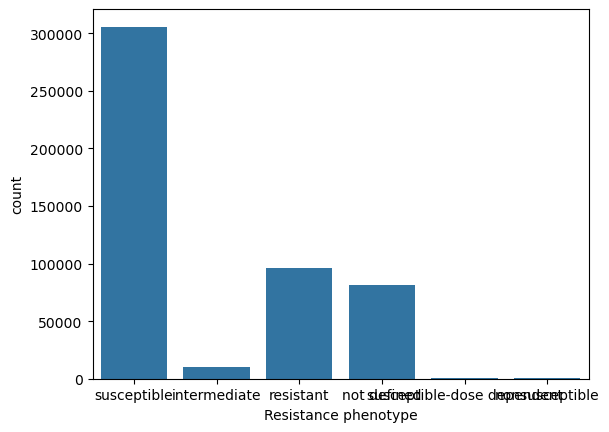

In [22]:
sns.countplot(x='Resistance phenotype', data=df)

plt.show()

In [23]:
df.describe()

,MIC (mg/L),Disk diffusion (mm)
count,482566.000000,6124.000000
mean,13.266598,19.196873
std,40.946756,11.176660
min,0.001000,6.000000
25%,0.500000,6.000000
50%,2.000000,19.000000
75%,8.000000,27.000000
max,1024.000000,70.000000


In [24]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("-"*40)

BioSample
35999
----------------------------------------
Organism group
52
----------------------------------------
Scientific name
549
----------------------------------------
Isolation type
2
----------------------------------------
Location
386
----------------------------------------
Isolation source
1195
----------------------------------------
Isolate
36010
----------------------------------------
Antibiotic
143
----------------------------------------
Resistance phenotype
6
----------------------------------------
Measurement sign
6
----------------------------------------
MIC (mg/L)
100
----------------------------------------
Disk diffusion (mm)
83
----------------------------------------
Laboratory typing platform
19
----------------------------------------
Vendor
14
----------------------------------------
Laboratory typing method version or reagent
24
----------------------------------------
Testing standard
5
----------------------------------------
Create date
15518
-----

## Next steps for this AMR project

### 1) Use the folder structure intentionally
- `data/raw/`: keep the original CSV untouched.
- `data/processed/`: save cleaned tables and feature-ready datasets.
- `models/`: save trained estimators and encoders.
- `notebooks/`: keep experimentation and model-building notebooks here.
- `reports/`: store plots, evaluation tables, and SHAP figures.

### 2) Cleaning
Why: the model will only be as good as the signal in the rows you keep.

What to do:
- Remove duplicates only after checking whether they are true duplicates or repeated measurements.
- Inspect columns with very high missingness and decide whether to drop or keep them.
- Separate numeric and categorical columns so each can be handled correctly.

### 3) Missing values
Why: tree models can handle some missingness poorly depending on encoding, and missingness can create leakage or noise.

What to do:
- For numeric columns, impute with median if the missing rate is acceptable.
- For categorical columns, impute with a dedicated label such as `Unknown`.
- Drop a column only if it is mostly missing and not important for the prediction task.

### 4) Target selection
The current target candidate is `Resistant Phenotype`.

Recommended decision:
- If you want a simpler first model, turn this into binary classification: `Susceptible` vs `Resistant`.
- If you keep the other classes, you are doing multiclass classification, which is valid but harder to interpret and evaluate.
- Remove labels like `Intermediate`, `Not defined`, or other rare classes unless you explicitly want to model them.

### 5) Feature engineering
Why: most columns in this dataset are metadata, so the model needs a clean numeric representation.

What to do:
- Keep informative columns such as antibiotic, testing method, platform, vendor, source, and year if they help prediction.
- Drop obvious identifier-like columns such as genome IDs if they do not generalize.
- One-hot encode low-cardinality categorical features.
- Consider grouping very rare categories into `Other`.
- If genome-level leakage is possible, split by genome rather than by row.

### 6) Train/test split
Why: this gives an honest estimate of generalization.

What to do:
- Use a stratified split so both classes appear in train and test.
- If the same genome appears multiple times, use a group split on `Genome ID` to avoid leakage.

### 7) Random Forest baseline
Why: you need a simple benchmark before using a stronger model.

What to do:
- Build a preprocessing pipeline with imputation and encoding.
- Train a Random Forest classifier.
- Evaluate with accuracy, precision, recall, F1, and confusion matrix.
- Save the model if it is a usable baseline.

### 8) XGBoost
Why: this is usually a stronger tabular-data model than a plain Random Forest.

What to do:
- Reuse the same preprocessing pipeline.
- Train XGBoost with tuned depth, learning rate, and number of estimators.
- Compare its validation scores against the Random Forest baseline.

### 9) SHAP explanations
Why: this tells you which features drive the predictions.

What to do:
- Use SHAP on the trained XGBoost model.
- Produce a global summary plot and a few local explanations.
- Save the plots into `reports/`.

### 10) Suggested order to implement next
1. Decide whether the target is binary or multiclass.
2. Define the final feature set.
3. Build the preprocessing pipeline.
4. Run the train/test split.
5. Train Random Forest first.
6. Train XGBoost second.
7. Run SHAP only after the final model is stable.

If you want, the next cell I add can be a ready-to-run preprocessing and modeling template for this exact dataset.